# M8.2 — CNN encoder machinery proof of concept

Plan: [`plans/milestone_08/08_single_view_localization_plan.md`](../../plans/milestone_08/08_single_view_localization_plan.md).  
Final Report: §5 setup shows a forward pass; **not** a single-image overfit.  

**Conclusion:** Single-view / single-particle overfit is a **machinery test** (optimiser + shapes + loss), not a capacity study. Prefer `anomaly_ref` + per-view z-score to match the frozen M8 protocol.


In [1]:
from pathlib import Path
import shutil
import sys
import subprocess

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists():
    if ROOT == ROOT.parent:
        raise RuntimeError("Could not locate repository root containing pyproject.toml")
    ROOT = ROOT.parent

# Concurrent notebook installs race on ./build (Errno 17 File exists).
for name in ("build", "dist"):
    shutil.rmtree(ROOT / name, ignore_errors=True)
for egg in (ROOT / "src").glob("*.egg-info"):
    shutil.rmtree(egg, ignore_errors=True)

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--no-cache-dir",
        f"{ROOT}[dl,dev]",
        "-c",
        str(ROOT / "requirements.txt"),
    ]
)

from gummybear.paths import display_path

print(f"ROOT={display_path(ROOT)}")



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
ROOT=.


In [2]:
from tomography_ml_validation.milestone_08 import m8_corpus_paths, describe_paths

DATA_MODE = "demo" if (ROOT / "data/generated/m8_demo").is_dir() else "full"
paths = m8_corpus_paths(ROOT, data_mode=DATA_MODE)
print(f"DATA_MODE={DATA_MODE}")
print(describe_paths(paths))


DATA_MODE=demo
workbook_path=configs/m8/m8_demo.xlsx  output_root=data/generated/m8_demo  cache_root=data/generated/m8_demo/_cache


In [3]:
import torch
from torch.nn.functional import mse_loss
import numpy as np
import matplotlib.pyplot as plt

from tomography_ml import get_device
from tomography_ml.localization import Encode, LocalizeSingleView
from tomography_ml_validation.milestone_08 import (
    build_m8_localization_dataset,
    default_single_view_task,
)
from gummybear.geometry import load_stl
from gummybear_validation.milestone_08 import (
    particle_dict_from_catalog_row,
    plot_localization_trajectory_in_mesh,
    resolve_job_stl_path,
)
from tomography_ml.gummybear_data_catalog import load_catalog_jobs

device = get_device()
print(f"device={device}")


device=mps


## Dry-run shapes


In [4]:
sample = torch.randn(4, 1, 224, 224, device=device)
localizer = LocalizeSingleView(Encode()).to(device)
out = localizer(sample)
print("dummy forward", tuple(out.shape))
assert out.shape == (4, 3)


dummy forward (4, 3)


## Load one single-view sample (frozen angle 180°)


In [5]:
task = default_single_view_task(
    keep_angles_deg=180.0,
    optical_setup_id=None if DATA_MODE == "demo" else "opt_m8_high_001",
)
dataset, task = build_m8_localization_dataset(ROOT, data_mode=DATA_MODE, task=task)
assert len(dataset) >= 1, "Need at least one complete train row"
x, y = dataset[0]
image = torch.tensor(x["anomaly_ref"], dtype=torch.float32, device=device)
target = torch.tensor(
    [y["particle_x"], y["particle_y"], y["particle_z"]],
    dtype=torch.float32,
    device=device,
).unsqueeze(0)
print("image", tuple(image.shape), "target", tuple(target.shape))
print("sequence", dataset.rows[0].sequence_id)


image (1, 1, 128, 128) target (1, 3)
sequence bear_m8_high_000002


## Overfit one image (short proof of concept)

Machinery check only — not a generalisation claim.


In [6]:
localizer = LocalizeSingleView(Encode()).to(device)
optimizer = torch.optim.Adam(localizer.parameters(), lr=3e-3)
trajectory = []
losses = []
NUM_STEPS = 150
for step in range(NUM_STEPS):
    optimizer.zero_grad(set_to_none=True)
    pred = localizer(image)
    loss = mse_loss(pred, target)
    loss.backward()
    optimizer.step()
    if step % 10 == 0 or step == NUM_STEPS - 1:
        trajectory.append(pred.detach().cpu().numpy()[0])
        losses.append(float(loss.item()))
trajectory = np.asarray(trajectory)
print(f"final MSE={losses[-1]:.6g}  pred={trajectory[-1]}  target={target.detach().cpu().numpy()[0]}")
assert losses[-1] < losses[0], "proof of concept: loss should decrease on a single sample" 


final MSE=2.20449e-06  pred=[ 5.599867  -4.329466   6.0618386]  target=[ 5.600813  -4.330757   6.0638514]


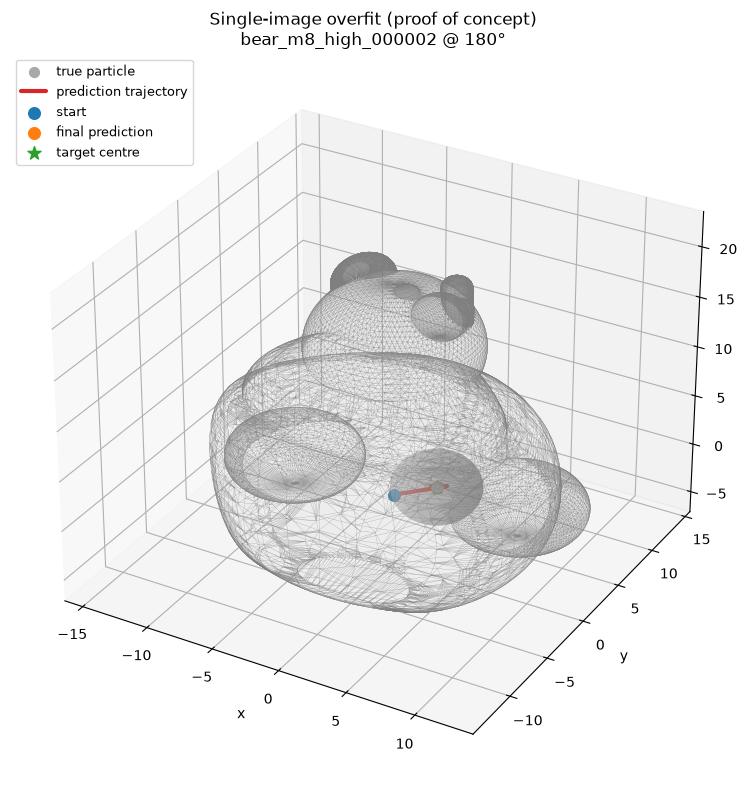

In [7]:
row = dataset.rows[0]
jobs = load_catalog_jobs(paths["workbook_path"], paths["repo_root"], stl_root=ROOT)
job = next(j for j in jobs if j.sequence_id == row.sequence_id)
surface_mesh = load_stl(resolve_job_stl_path(job, stl_root=ROOT))
particle = particle_dict_from_catalog_row(row)

fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(111, projection="3d")
plot_localization_trajectory_in_mesh(
    ax,
    surface_mesh,
    particle,
    trajectory,
    target=target.detach().cpu().numpy(),
    mesh_alpha=0.10,
    particle_alpha=0.35,
    trajectory_color="tab:red",
    trajectory_linewidth=3.0,
    title=f"Single-image overfit (proof of concept)\n{row.sequence_id} @ 180°",
)
plt.tight_layout()
plt.show()
